## Markov Chain

In this excersice our goal is to predict tomorrow's weathe and from previous observations we know that:
The probabilities of having clear/cloudy skies tomorrow, given that today is cloudy, are:
$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$
given that today is clear:
$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$

In order to achieve our aims, based on those probabilities, we want to set a markov chain to explore the probability distribuition of clear days and exctract the most probable value and an error around our estimate

In [9]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
import random
from astroML import stats

In [4]:

#Cloudy days correspond to 0 and clear days to 1
#Starting from a cloudy day
ci = 0
N = 100000

possib = np.zeros(10)
weather_tot = []
clear_days = []
cloudy_days = []
cloudy_days.append(0)
weather_tot.append(ci)

clear_count = 0
cloudy_count = 0
#array for the cumulative fraction of clear/cloudy days
cum_clear = []
cum_cloudy = []
cum_cloudy.append(0)

for i in range(1,N+1):

    #check if previous step was cloudy
    if weather_tot[i-1] == 0:
        #setting 50% probability for a cloudy or sunny day
        possib[:5] = 0
        possib[5:] = 1
        
        weather = random.randint(0,9) #Extracting an index in order to determine the weather
        ci = possib[weather]
        weather_tot.append(ci)
        
        if ci== 1:
            clear_count = clear_count+1
        else:
            cloudy_count = cloudy_count +1
            
    #check if previous step was clear
    if weather_tot[i-1] == 1:
        possib[0] = 0 
        possib[1:] = 1
    
        weather = random.randint(0,9)
        ci = possib[weather]
      
        weather_tot.append(ci)
        
        if ci == 1:
            clear_count = clear_count+1
        else:
            cloudy_count = cloudy_count +1
            
    #keeping track of the number of cloudy/clear days
    cloudy_days.append(i)
    clear_days.append(i)
    cum_clear.append(clear_count)
    cum_cloudy.append(cloudy_count)

weather_tot = np.array(weather_tot)
#computing probabilities
prob_clear = len(weather_tot[weather_tot>0])/len(weather_tot)
prob_cloudy = len(weather_tot[weather_tot<1])/len(weather_tot)
print(prob_clear)
print(prob_cloudy)
#computing the cumulative fraction of cloudy days and clear days
cum_clear = np.array(cum_clear)
cum_cloudy = np.array(cum_cloudy)
cum_clear = cum_clear/clear_days
cum_cloudy = cum_cloudy/cloudy_days
print(cum_clear)


0.8341916580834192
0.16580834191658084
[1.         1.         0.66666667 ... 0.83419668 0.83419834 0.8342    ]


C:\Users\alexv\AppData\Local\Temp\ipykernel_18864\797614996.py:68: RuntimeWarning: invalid value encountered in divide
  cum_cloudy = cum_cloudy/cloudy_days


Let's plot the trace plot for the cumulative fraction of clear days and cloudy days.

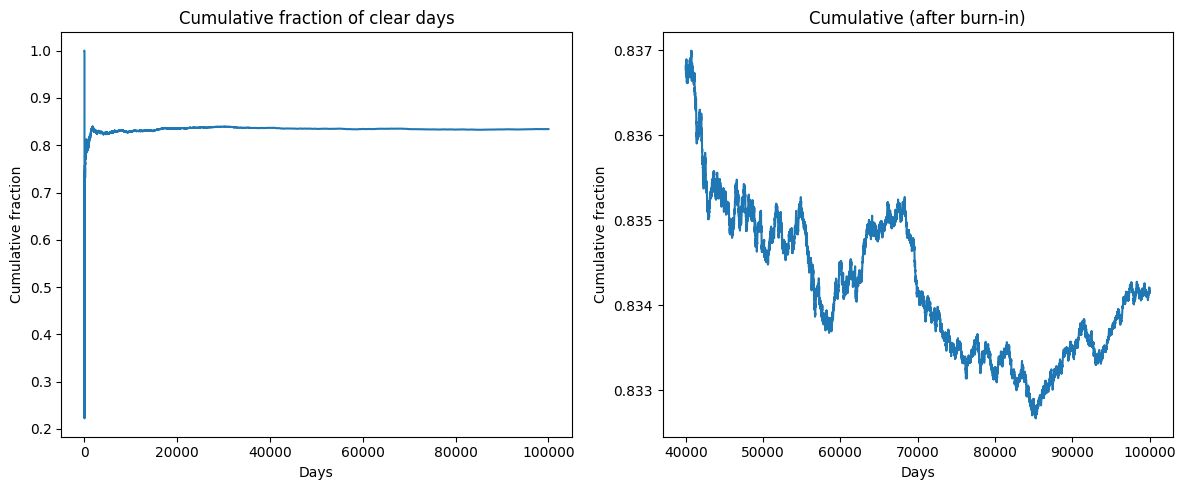

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#Trace plot:
axes[0].plot(clear_days, cum_clear)
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title("Cumulative fraction of clear days")

# After burn-in:
trunc_clear = cum_clear[40000:]
trunc_days = clear_days[40000:]
axes[1].plot(trunc_days, trunc_clear)
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Cumulative (after burn-in)")

plt.tight_layout()
plt.show()

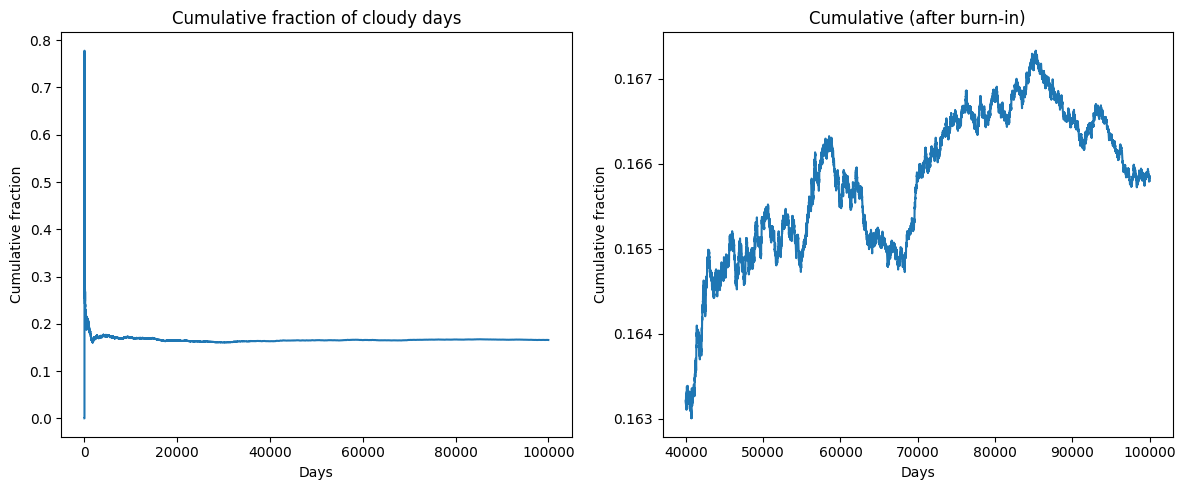

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#Trace plot:
axes[0].plot(cloudy_days, cum_cloudy)
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title("Cumulative fraction of cloudy days")

# After burn-in:
trunc_cloudy = cum_cloudy[40000:]
trunc_days_cloudy = cloudy_days[40000:]
axes[1].plot(trunc_days_cloudy, trunc_cloudy)
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Cumulative (after burn-in)")

plt.tight_layout()
plt.show()

### Posterior distribuition of clear days and cloudy days

Clear days — Most frequent value: 0.833
Cloudy days — Most frequent value: nan


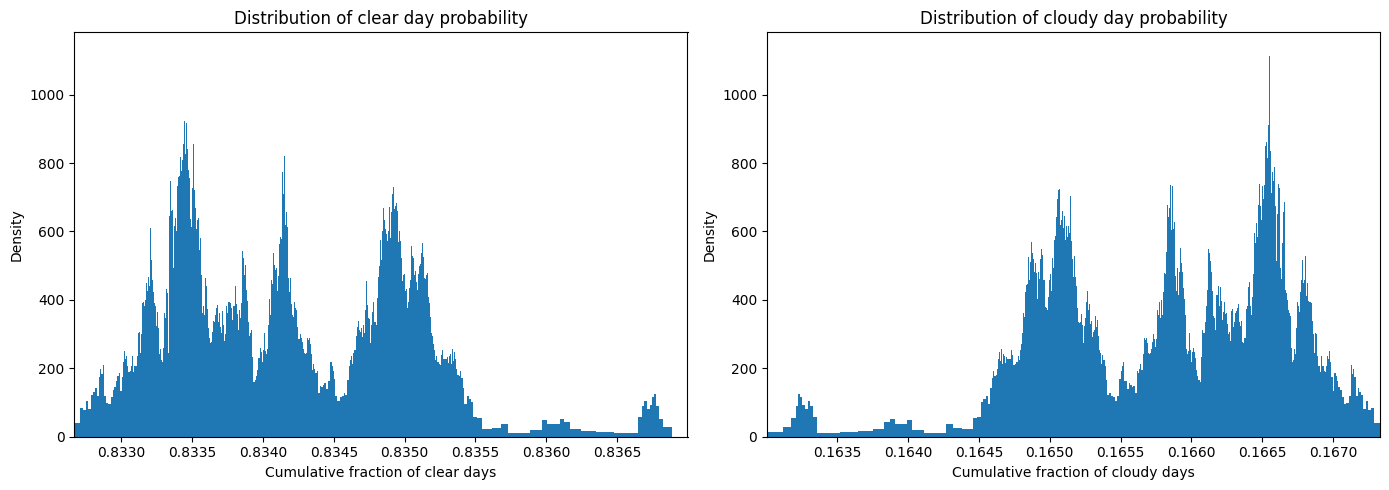

In [7]:
bins100 = np.append(np.sort(trunc_clear)[::100], np.max(cum_clear))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Clear days histogram
counts_clear, edges_clear, _ = axes[0].hist(trunc_clear, bins=bins100, density=True)
max_idx_clear = np.argmax(counts_clear)
mode_clear = (edges_clear[max_idx_clear] + edges_clear[max_idx_clear + 1]) / 2
axes[0].set_xlabel("Cumulative fraction of clear days")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of clear day probability")
axes[0].set_xlim(np.min(trunc_clear), np.max(trunc_clear))

print(f'Clear days — Most frequent value: {mode_clear:.3f}')
bins100_c = np.append(np.sort(trunc_cloudy)[::100], np.max(cum_cloudy))
counts_cloudy, edges_cloudy, _ = axes[1].hist(trunc_cloudy, bins=bins100_c, density=True)
max_idx_cloudy = np.argmax(counts_cloudy)
mode_cloudy = (edges_cloudy[max_idx_cloudy] + edges_cloudy[max_idx_cloudy + 1]) / 2
axes[1].set_xlabel("Cumulative fraction of cloudy days")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of cloudy day probability")
axes[1].set_xlim(np.min(trunc_cloudy), np.max(trunc_cloudy))

print(f'Cloudy days — Most frequent value: {mode_cloudy:.3f}')

plt.tight_layout()
plt.show()


In [15]:
#Computing statistics
print(f'Median of clear days probability: {np.median(trunc_clear)} +- {astroML.stats.sigmaG(trunc_clear)}' )
print(f'Median of cloudy days probability: {np.median(trunc_cloudy)} +- {astroML.stats.sigmaG(trunc_cloudy)}' )



Median of clear days probability: 0.8341161528343769 +- 0.001054309809811718
Median of cloudy days probability: 0.16588381709422298 +- 0.0010543171111145463
